# Notebook 3 | Interactive Hazard Maps
## International Training Course on Seismology, Seismic Data Analysis, Hazard Assessment and Risk Mitigation · Potsdam, June 2026

**Purpose:** Download spatial hazard grids from the EFEHR Services API and produce geographic maps of seismic hazard over Italy and the Mediterranean.

### What you will learn
- How to download and parse a spatial hazard map from the new EFEHR JSON API
- How to plot and interpret ground-motion maps with a geographic backdrop
- How spatial hazard patterns relate to tectonic structure
- How hazard changes with return period across a region
- How to compare two IMTs spatially (PGA vs SA)
- How to overlay ESHM20 input datasets (faults, source zones) via the OGC API
- How to create interactive web maps with WMS hazard tiles and site-specific information

### Workflow
```
Notebook 1           →  hazard_config.yaml  →  Notebook 3
(discovery, Messina)     (models + PoEs)        (spatial maps)
```

**Prerequisite:** `hazard_config.yaml` from Notebook 1 must exist in the same folder.

### Services used in this notebook

| Service | URL | What it provides |
|---------|-----|-----------------|
| **REST API** | `efehr-services.ethz.ch/hazard/api` | Hazard grids via `/v1/maps/area` (JSON) |
| **WMS** | `efehr-services.ethz.ch/hazard/ows/eshm20-output` | Pre-rendered hazard tiles for folium |
| **OGC API Features** | `efehr-services.ethz.ch/hazard/ows/eshm20-input/ogcapi` | ESHM20 input datasets as GeoJSON |

### The `/v1/maps/area` endpoint

The API exposes a `/v1/maps/area` endpoint that returns a spatial grid of pre-computed hazard values for a bounding box:

```
GET /v1/maps/area?modelid={id}&imt={imt}&poe={P}&timespan={T}
                 &lon_min={W}&lat_min={S}&lon_max={E}&lat_max={N}
                 [&soil_type=rock_vs30_800ms-1]
                 [&aggregation_type=arithmetic&aggregation_level=0.5]
```

Response: `{"points": [{"lon": …, "lat": …, "value": …}, …]}`

Each point is a pre-computed grid node (~0.1° spacing for ESHM20). A bounding box request for Southern Italy returns ~1500–2000 nodes and completes in seconds — far faster than the old XML/shapefile approach.

## 1. Install dependencies

In [1]:
import subprocess, sys

subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'pyyaml', 'requests', 'matplotlib', 'numpy', 'scipy',
                       'pyshp'])   # lightweight shapefile reader (no GDAL required)

try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'cartopy'])
    print('cartopy installed.')
except Exception:
    print('cartopy not available — will use fallback matplotlib map.')

try:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'folium'])
    print('folium installed.')
except Exception:
    print('folium not available — Exercise E will be skipped.')

print('\nAll required dependencies ready.')

cartopy installed.
folium installed.

All required dependencies ready.


## 2. Imports and environment detection

In [2]:
import requests
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.colors import BoundaryNorm, LogNorm
import numpy as np
from scipy.interpolate import griddata
import io, yaml, sys, math

# Optional imports — degrade gracefully if not available
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
    print('cartopy available: geographic projections and coastlines enabled.')
except ImportError:
    HAS_CARTOPY = False
    print('cartopy not available: using simple matplotlib maps.')

try:
    import folium
    HAS_FOLIUM = True
    print('folium available: interactive HTML maps enabled.')
except ImportError:
    HAS_FOLIUM = False
    print('folium not available: Exercise E will be skipped.')

BASE_URL    = 'http://appsrvr.share-eu.org:8080/share'
CONFIG_FILE = 'hazard_config.yaml'
MAP_POES    = {}      # populated by the probe cell; guards resolve_poe() NameError
MODELS      = {}      # populated by Cell 5 (load_config); guards exercise cells

cartopy available: geographic projections and coastlines enabled.
folium available: interactive HTML maps enabled.


## 3. API helpers and map data fetcher

In [3]:

# =============================================================================
# SHARE /map API — how it actually works
#
# Level 1: /map?id=M&imt=I
#            → <exceedances> listing available PoEs
#
# Level 2: /map?id=M&imt=I&hmapexceedprob=P&hmapexceedyears=Y
#            → <fractiles> listing available aggregations
#
# Level 3: /map?id=M&imt=I&hmapexceedprob=P&hmapexceedyears=Y
#                          &aggregationtype=T&aggregationlevel=L&soiltype=S
#            → <hmapid>, <hmapwms>  — layer name, no direct data download URL
#
# Data retrieval strategy (in order of preference):
#   4a. hazardmaplocation URL  — present for some older model versions
#   4b. Pre-computed shapefile ZIP from staticdownload server
#         https://efehrappsrvr.ethz.ch/share/staticdownload/{hmapwms}.zip
#   4c. /curve grid sampling   — always works; ~4 min at 0.5° for S. Italy
# =============================================================================

STATICDOWNLOAD_URL = 'https://efehrappsrvr.ethz.ch/share/staticdownload'


def get_xml_root(url, debug=False):
    """Fetch URL, parse XML, strip namespace prefixes. Returns (root, raw_text)."""
    try:
        if debug:
            print(f'  GET {url}')
        r = requests.get(url, timeout=120)
        if r.status_code != 200:
            if debug:
                print(f'  HTTP {r.status_code}: {r.text[:200]}')
            return None, r.text if r.text else None
        it = ET.iterparse(io.StringIO(r.text))
        for _, el in it:
            _, _, el.tag = el.tag.rpartition('}')
        return it.root, r.text
    except Exception as e:
        if debug:
            print(f'  Error: {e}')
        return None, None


def probe_map_poes(model_id, imt):
    """Level 1: return list of {prob, years} dicts available for this model/IMT."""
    url = f'{BASE_URL}/map?id={model_id}&imt={imt}'
    root, _ = get_xml_root(url)
    if root is None:
        return []
    poes, seen = [], set()
    for exc in root.iter():
        if 'exceedance' not in exc.tag.lower():
            continue
        p = exc.find('hmapexceedprob')
        y = exc.find('hmapexceedyears')
        if p is not None and y is not None and p.text and y.text:
            key = (p.text.strip(), y.text.strip())
            if key not in seen:
                seen.add(key)
                poes.append({'prob': key[0], 'years': key[1]})
    return poes


def probe_map_aggregations(model_id, imt, poe_prob, poe_years):
    """Level 2: return list of {type, level} dicts for this model/IMT/PoE."""
    url = (f'{BASE_URL}/map?id={model_id}&imt={imt}'
           f'&hmapexceedprob={poe_prob}&hmapexceedyears={poe_years}')
    root, _ = get_xml_root(url)
    if root is None:
        return []
    aggs, seen = [], set()
    for f in root.iter():
        if 'fractile' not in f.tag.lower():
            continue
        t = f.find('aggregationtype')
        l = f.find('aggregationlevel')
        if t is not None and l is not None and t.text and l.text:
            key = (t.text.strip(), l.text.strip())
            if key not in seen:
                seen.add(key)
                aggs.append({'type': key[0], 'level': key[1]})
    return aggs


def get_map_reference(model_id, imt, poe_prob, poe_years,
                       agg_type, agg_level, soil, debug=False):
    """Level 3: returns dict with hmapid, hmapwms (and hazardmaplocation if present)."""
    url = (f'{BASE_URL}/map?id={model_id}&imt={imt}'
           f'&hmapexceedprob={poe_prob}&hmapexceedyears={poe_years}'
           f'&soiltype={soil}'
           f'&aggregationtype={agg_type}&aggregationlevel={agg_level}')
    if debug:
        print(f'  Level 3 URL: {url}')
    root, _ = get_xml_root(url, debug=debug)
    if root is None:
        return None

    ref = {}
    for elem in root.iter():
        tag = elem.tag.lower()
        txt = elem.text.strip() if elem.text and elem.text.strip() else None
        if txt:
            if 'hmapid'            in tag: ref['hmapid']            = txt
            if 'hmapwms'           in tag: ref['hmapwms']           = txt
            if 'hazardmaplocation' in tag: ref['hazardmaplocation'] = txt
            if 'hazardmaplocation' not in ref:
                if txt.startswith('http') and any(
                        x in tag for x in ('map', 'location', 'url', 'data')):
                    ref['hazardmaplocation'] = txt
        for attr_val in elem.attrib.values():
            if isinstance(attr_val, str) and attr_val.startswith('http'):
                if 'hazardmaplocation' not in ref:
                    ref['hazardmaplocation'] = attr_val

    if debug:
        print('  All elements in Level 3 response:')
        for elem in root.iter():
            if elem.text and elem.text.strip():
                print(f'    <{elem.tag}> {elem.text.strip()[:120]}')
            if elem.attrib:
                print(f'    <{elem.tag}> attrs={elem.attrib}')
        print(f'  Parsed reference: {ref}')
    return ref if ref else None


def _fetch_via_shapefile(hmapwms, bbox, debug=False):
    """
    Download pre-computed shapefile ZIP from the EFEHR staticdownload server,
    unzip in memory, read with pyshp, and return (lons, lats, vals) arrays.

    URL pattern: https://efehrappsrvr.ethz.ch/share/staticdownload/{hmapwms}.zip
    The shapefile records contain a numeric value attribute (hazard IML in g).
    """
    import zipfile
    import shapefile  # pyshp

    zip_url = f'{STATICDOWNLOAD_URL}/{hmapwms}.zip'
    print(f'  4b: shapefile ZIP download: {zip_url}')

    try:
        r = requests.get(zip_url, timeout=120)
        if r.status_code != 200:
            print(f'  HTTP {r.status_code} — ZIP not available for {hmapwms}')
            return None, None, None

        # Unzip in memory
        zf = zipfile.ZipFile(io.BytesIO(r.content))
        names = zf.namelist()
        if debug:
            print(f'  ZIP contents: {names}')

        # Find the .shp / .dbf / .shx components
        shp_name = next((n for n in names if n.lower().endswith('.shp')), None)
        dbf_name = next((n for n in names if n.lower().endswith('.dbf')), None)
        shx_name = next((n for n in names if n.lower().endswith('.shx')), None)

        if shp_name is None or dbf_name is None:
            print(f'  No .shp/.dbf found in ZIP ({names})')
            return None, None, None

        shp_io = io.BytesIO(zf.read(shp_name))
        dbf_io = io.BytesIO(zf.read(dbf_name))
        shx_io = io.BytesIO(zf.read(shx_name)) if shx_name else None

        sf = shapefile.Reader(shp=shp_io, dbf=dbf_io,
                              **({'shx': shx_io} if shx_io else {}))

        # Discover which field contains the hazard value (first numeric field)
        fields = sf.fields[1:]  # skip DeletionFlag
        if debug:
            print(f'  DBF fields: {fields}')

        val_idx = None
        for i, f in enumerate(fields):
            if f[1] in ('N', 'F'):  # numeric types in DBF
                val_idx = i
                if debug:
                    print(f'  Using value field: {f[0]} (index {i})')
                break

        if val_idx is None:
            print(f'  No numeric field found in shapefile ({[f[0] for f in fields]})')
            return None, None, None

        lons_out, lats_out, vals_out = [], [], []
        lon_min, lat_min, lon_max, lat_max = bbox if bbox else (-180, -90, 180, 90)

        for shape_rec in sf.iterShapeRecords():
            geom = shape_rec.shape
            rec  = shape_rec.record

            # Point geometry: use the point coordinates directly
            if geom.shapeType in (1, 11, 21):  # Point, PointZ, PointM
                if not geom.points:
                    continue
                lon, lat = geom.points[0]
            else:
                # Polygon/polyline: use the centroid of the bounding box
                if not geom.bbox or len(geom.bbox) < 4:
                    continue
                lon = (geom.bbox[0] + geom.bbox[2]) / 2
                lat = (geom.bbox[1] + geom.bbox[3]) / 2

            # Bbox filter
            if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
                continue

            try:
                val = float(rec[val_idx])
                if val > 0:
                    lons_out.append(lon)
                    lats_out.append(lat)
                    vals_out.append(val)
            except (TypeError, ValueError):
                pass

        if not lons_out:
            print('  Shapefile read OK but no points passed bbox / value filter.')
            return None, None, None

        print(f'  ✓ {len(lons_out)} points read from shapefile')
        return np.array(lons_out), np.array(lats_out), np.array(vals_out)

    except Exception as e:
        if debug:
            import traceback; traceback.print_exc()
        print(f'  Shapefile error: {e}')
        return None, None, None


def _fetch_via_curve_grid(model_id, imt, poe_prob, poe_years,
                           soil, agg_type, agg_level,
                           bbox, grid_spacing=0.5, debug=False):
    """
    Build a spatial hazard map by sampling the /curve endpoint on a regular grid
    and interpolating each hazard curve to the target return period.

    grid_spacing: degrees between grid points.
      0.5° → ~196 points for Southern Italy (~4 min)
      1.0° → ~49 points (~1 min, coarser map)
    """
    if bbox is None:
        bbox = (6.5, 36.0, 19.0, 47.5)

    lon_min, lat_min, lon_max, lat_max = bbox
    lons_g = np.arange(lon_min, lon_max + grid_spacing, grid_spacing)
    lats_g = np.arange(lat_min, lat_max + grid_spacing, grid_spacing)

    yr = float(poe_years)
    pr = float(poe_prob)
    annual_rate = pr if yr == 1 else -math.log(1 - pr) / yr

    n_total = len(lons_g) * len(lats_g)
    print(f'  /curve grid sampling: {n_total} points at {grid_spacing}° '
          f'(annual rate = {annual_rate:.5g})...')

    lons_out, lats_out, vals_out = [], [], []
    done = 0

    for lat in lats_g:
        for lon in lons_g:
            url = (f'{BASE_URL}/curve?id={model_id}&lon={lon}&lat={lat}'
                   f'&imt={imt}&soiltype={soil}'
                   f'&aggregationtype={agg_type}&aggregationlevel={agg_level}')
            root, _ = get_xml_root(url, debug=False)
            if root is not None:
                imls, poes_c = [], []
                for elem in root.iter():
                    tag = elem.tag.lower()
                    if 'iml' in tag and elem.text:
                        try:
                            imls = [float(x) for x in elem.text.split()]
                        except ValueError:
                            pass
                    if tag in ('poe', 'ep', 'poes') and elem.text:
                        try:
                            poes_c = [float(x) for x in elem.text.split()]
                        except ValueError:
                            pass
                if imls and poes_c and len(imls) == len(poes_c) >= 2:
                    try:
                        pairs = [(i, p) for i, p in zip(imls, poes_c)
                                 if i > 0 and p > 0]
                        if len(pairs) >= 2:
                            log_imls = np.array([math.log(p[0]) for p in pairs])
                            log_poes = np.array([math.log(p[1]) for p in pairs])
                            if log_poes[0] > log_poes[-1]:
                                iml_val = math.exp(float(np.interp(
                                    math.log(annual_rate),
                                    log_poes[::-1], log_imls[::-1])))
                                lons_out.append(lon)
                                lats_out.append(lat)
                                vals_out.append(iml_val)
                    except Exception:
                        pass
            done += 1
            if done % 20 == 0 or done == n_total:
                print(f'    {done}/{n_total} done, '
                      f'{len(vals_out)} values obtained...')

    if not lons_out:
        return None, None, None
    return np.array(lons_out), np.array(lats_out), np.array(vals_out)


def _parse_map_text(content, bbox, debug=False):
    """Parse CSV or space-delimited grid data from a direct download URL."""
    lons, lats, vals = [], [], []
    lines = [l.strip() for l in content.strip().splitlines() if l.strip()]
    sep = ',' if (lines and ',' in lines[0]) else None
    for line in lines:
        parts = line.split(sep) if sep else line.split()
        if len(parts) >= 3:
            try:
                a, b, c = float(parts[0]), float(parts[1]), float(parts[2])
                if abs(a) >= abs(b):
                    lats.append(a); lons.append(b)
                else:
                    lons.append(a); lats.append(b)
                vals.append(c)
            except ValueError:
                pass
    if not lons:
        return None, None, None
    return _apply_bbox(np.array(lons), np.array(lats), np.array(vals), bbox)


def _apply_bbox(lons, lats, vals, bbox):
    if bbox is None:
        return lons, lats, vals
    lon_min, lat_min, lon_max, lat_max = bbox
    mask = ((lons >= lon_min) & (lons <= lon_max) &
            (lats >= lat_min) & (lats <= lat_max))
    return lons[mask], lats[mask], vals[mask]


def fetch_map(model_id, imt, poe_prob, poe_years,
              soil='rock_vs30_800ms-1',
              agg_type='arithmetic', agg_level='0.5',
              bbox=None, grid_spacing=0.5, debug=False):
    """
    Fetch a spatial hazard map via three-level fallback:

    4a. hazardmaplocation URL  (direct download; rarely present)
    4b. Pre-computed shapefile ZIP from staticdownload server (fast, full coverage)
    4c. /curve grid sampling   (always works; ~4 min at 0.5° for S. Italy)

    grid_spacing: used only for 4c fallback (default 0.5°).
    Use 1.0° for a quick preview during live demos.
    """
    print(f'Fetching map: {imt}, PoE={poe_prob}/{poe_years}yr')

    ref = get_map_reference(model_id, imt, poe_prob, poe_years,
                            agg_type, agg_level, soil, debug=debug)

    lons = lats = vals = None

    # 4a: direct hazardmaplocation URL
    if ref and ref.get('hazardmaplocation'):
        loc = ref['hazardmaplocation']
        if debug:
            print(f'  4a: hazardmaplocation {loc}')
        try:
            r = requests.get(loc, timeout=120)
            if r.status_code == 200 and len(r.text) > 50:
                lons, lats, vals = _parse_map_text(r.text, bbox, debug)
        except Exception as e:
            if debug:
                print(f'  4a error: {e}')

    # 4b: pre-computed shapefile ZIP (primary data path for ESHM20 and ESHM13)
    if (lons is None or len(lons) == 0) and ref and ref.get('hmapwms'):
        lons, lats, vals = _fetch_via_shapefile(
            ref['hmapwms'], bbox=bbox, debug=debug)
        if lons is not None and len(lons) > 0 and bbox is not None:
            lons, lats, vals = _apply_bbox(lons, lats, vals, bbox)

    # 4c: /curve grid sampling (always works, slower)
    if lons is None or len(lons) == 0:
        print(f'  4c: /curve grid sampling (grid_spacing={grid_spacing}°)...')
        lons, lats, vals = _fetch_via_curve_grid(
            model_id, imt, poe_prob, poe_years,
            soil, agg_type, agg_level,
            bbox=bbox, grid_spacing=grid_spacing, debug=debug)

    if lons is None or len(lons) == 0:
        print('  ✗ All data retrieval strategies failed.')
        return None

    print(f'  ✓ {len(lons)} nodes  |  '
          f'{imt} range: {vals.min():.4f}–{vals.max():.4f} g')
    return {'lons': lons, 'lats': lats, 'values': vals,
            'imt': imt, 'poe': poe_prob, 'n_nodes': len(lons),
            'wms_url': ref.get('hmapwms', '') if ref else ''}


def probe_map_raw(model_id, imt, poe_prob=None, poe_years=None,
                  agg_type=None, agg_level=None, soil=None, n_chars=800):
    """Print raw XML at each /map cascade level for diagnostics."""
    levels = [f'{BASE_URL}/map?id={model_id}&imt={imt}']
    if poe_prob:
        levels.append(f'{BASE_URL}/map?id={model_id}&imt={imt}'
                      f'&hmapexceedprob={poe_prob}&hmapexceedyears={poe_years or "1"}')
    if poe_prob and agg_type and soil:
        levels.append(f'{BASE_URL}/map?id={model_id}&imt={imt}'
                      f'&hmapexceedprob={poe_prob}&hmapexceedyears={poe_years or "1"}'
                      f'&soiltype={soil}'
                      f'&aggregationtype={agg_type}&aggregationlevel={agg_level or "0.5"}')
    for lvl_n, url in enumerate(levels, 1):
        print(f'\n--- Level {lvl_n} ---\nURL: {url}')
        try:
            r = requests.get(url, timeout=30)
            print(f'HTTP {r.status_code}  |  {len(r.text)} chars')
            print(r.text[:n_chars])
        except Exception as e:
            print(f'Error: {e}')


def resolve_poe(model_name, target_rp=475):
    """Return (prob, years) for the closest available RP from MAP_POES or config."""
    poes = MAP_POES.get(model_name, [])
    if not poes and config:
        for m in config['available_models']:
            if m['name'] == model_name:
                poes = m['parameters'].get('poes', [])
                break
    if not poes:
        return None, None
    best, best_diff = poes[0], float('inf')
    for p in poes:
        try:
            yr = float(p['years'])
            pr = float(p['prob'])
            ar = pr if yr == 1 else -math.log(1 - pr) / yr
            diff = abs(1 / ar - target_rp)
            if diff < best_diff:
                best_diff, best = diff, p
        except Exception:
            pass
    return best['prob'], best['years']


def load_config():
    try:
        with open(CONFIG_FILE) as f:
            cfg = yaml.safe_load(f)
        print(f'Config loaded — {cfg["location"]["latitude"]}N, '
              f'{cfg["location"]["longitude"]}E')
        return cfg
    except FileNotFoundError:
        print('ERROR: hazard_config.yaml not found. Run Notebook 1 first.')
        return None
    except Exception as e:
        print(f'ERROR: {e}')
        return None


print('API helpers loaded  (4a hazardmaplocation → 4b shapefile ZIP → 4c /curve).')

API helpers loaded  (4a hazardmaplocation → 4b shapefile ZIP → 4c /curve).


## 4. Map plotting engine

Two plotting backends are provided:
- **Cartopy** (if installed): proper Plate Carée projection with Natural Earth coastlines and country borders
- **Fallback**: standard matplotlib axes with a contour-fill over an interpolated grid

Both backends use `scipy.interpolate.griddata` to resample the scattered API output onto a regular lat/lon grid before contouring.

In [4]:
# ── colour map: white-yellow-orange-red-darkred (seismic hazard convention) ─
HAZARD_CMAP = 'YlOrRd'


def _make_grid(map_data, grid_res=0.1):
    """
    Resample scattered (lon, lat, value) triplets onto a regular grid.
    Returns (lon_grid, lat_grid, val_grid) as 2-D arrays.
    """
    lons = map_data['lons']
    lats = map_data['lats']
    vals = map_data['values']
    lon_g = np.arange(lons.min(), lons.max() + grid_res, grid_res)
    lat_g = np.arange(lats.min(), lats.max() + grid_res, grid_res)
    LON, LAT = np.meshgrid(lon_g, lat_g)
    VAL = griddata((lons, lats), vals, (LON, LAT), method='linear')
    return LON, LAT, VAL


def _colorbar_label(imt):
    return f'{imt} [g]'


def plot_map_cartopy(map_data, title='', vmin=None, vmax=None, ax=None,
                     log_scale=True, n_levels=15, show_colorbar=True):
    """Plot a hazard map using cartopy (proper geographic projection)."""
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    LON, LAT, VAL = _make_grid(map_data)
    masked = np.ma.masked_invalid(VAL)

    if vmin is None: vmin = np.nanpercentile(map_data['values'], 2)
    if vmax is None: vmax = np.nanpercentile(map_data['values'], 98)
    vmin = max(vmin, 1e-5)

    if log_scale and vmin > 0:
        levels = np.logspace(np.log10(vmin), np.log10(vmax), n_levels)
        norm   = LogNorm(vmin=vmin, vmax=vmax)
    else:
        levels = np.linspace(vmin, vmax, n_levels)
        norm   = None

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(1, 1, figsize=(10, 8),
                               subplot_kw={'projection': ccrs.PlateCarree()})

    ax.set_extent([LON.min(), LON.max(), LAT.min(), LAT.max()],
                  crs=ccrs.PlateCarree())
    cf = ax.contourf(LON, LAT, masked, levels=levels, cmap=HAZARD_CMAP,
                     norm=norm, transform=ccrs.PlateCarree(), extend='both')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.7, color='0.2')
    ax.add_feature(cfeature.BORDERS,   linewidth=0.5, color='0.4', linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='0.5')
    ax.gridlines(draw_labels=True, linewidth=0.4, color='grey', alpha=0.5, linestyle='--')
    ax.set_title(title, fontsize=11)

    if show_colorbar and own_fig:
        plt.colorbar(cf, ax=ax, label=_colorbar_label(map_data['imt']),
                     shrink=0.75, pad=0.08)
        plt.show()  # tight_layout() omitted — incompatible with cartopy GeoAxes

    return cf


def plot_map_simple(map_data, title='', vmin=None, vmax=None, ax=None,
                    log_scale=True, n_levels=15, show_colorbar=True):
    """Plot a hazard map using plain matplotlib (no cartopy required)."""
    LON, LAT, VAL = _make_grid(map_data)
    masked = np.ma.masked_invalid(VAL)

    if vmin is None: vmin = np.nanpercentile(map_data['values'], 2)
    if vmax is None: vmax = np.nanpercentile(map_data['values'], 98)
    vmin = max(vmin, 1e-5)

    if log_scale and vmin > 0:
        levels = np.logspace(np.log10(vmin), np.log10(vmax), n_levels)
        norm   = LogNorm(vmin=vmin, vmax=vmax)
    else:
        levels = np.linspace(vmin, vmax, n_levels)
        norm   = None

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(10, 8))

    cf = ax.contourf(LON, LAT, masked, levels=levels, cmap=HAZARD_CMAP,
                     norm=norm, extend='both')
    ax.contour(LON, LAT, masked, levels=levels, colors='k', linewidths=0.2, alpha=0.3)
    ax.set_xlabel('Longitude [°E]', fontsize=10)
    ax.set_ylabel('Latitude [°N]',  fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, linewidth=0.4, alpha=0.4, linestyle='--')
    ax.set_title(title, fontsize=11)

    if show_colorbar and own_fig:
        plt.colorbar(cf, ax=ax, label=_colorbar_label(map_data['imt']), shrink=0.75)
        plt.tight_layout()
        plt.show()

    return cf


def plot_map(map_data, title='', vmin=None, vmax=None, ax=None,
             log_scale=True, n_levels=15, show_colorbar=True):
    """Dispatcher: uses cartopy if available, otherwise plain matplotlib."""
    if HAS_CARTOPY:
        return plot_map_cartopy(map_data, title=title, vmin=vmin, vmax=vmax,
                                ax=ax, log_scale=log_scale, n_levels=n_levels,
                                show_colorbar=show_colorbar)
    else:
        return plot_map_simple(map_data, title=title, vmin=vmin, vmax=vmax,
                               ax=ax, log_scale=log_scale, n_levels=n_levels,
                               show_colorbar=show_colorbar)


def mark_cities(ax, cities, projection=None):
    """Overlay city markers on a map axis."""
    transform = projection if projection else None
    for city in cities:
        kw = dict(transform=transform) if transform else {}
        ax.plot(city['lon'], city['lat'], 'k^', markersize=6,
                markerfacecolor='white', markeredgewidth=1.2, **kw)
        ax.text(city['lon'] + 0.1, city['lat'] + 0.1, city['name'],
                fontsize=8, color='black',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7), **kw)


print('Plotting engine loaded.')

Plotting engine loaded.


## 5. Load configuration and define study region

In [5]:
config = load_config()

if config:
    MODELS = {m['name']: m for m in config['available_models']
              if m['name'] and m['parameters'].get('imts')}
    print(f'Usable models: {list(MODELS.keys())}')

# ── Geographic bounding boxes ──────────────────────────────────────────────
REGIONS = {
    'Southern Italy + Sicily':  (11.0, 36.0, 17.5, 42.5),  # lon_min, lat_min, lon_max, lat_max
    'Italy':                    ( 6.5, 36.0, 19.0, 47.5),
    'Messina Strait (zoom)':    (14.5, 37.5, 16.5, 39.0),
    'Central Mediterranean':    ( 5.0, 33.0, 25.0, 48.0),
    'Europe (full model)':      None,  # no bbox = full API domain
}

# ── Reference cities for annotation ────────────────────────────────────────
CITIES = [
    {'name': 'Messina',    'lat': 38.19, 'lon': 15.55},
    {'name': 'Catania',    'lat': 37.50, 'lon': 15.09},
    {'name': "L'Aquila",   'lat': 42.35, 'lon': 13.40},
    {'name': 'Naples',     'lat': 40.85, 'lon': 14.27},
    {'name': 'Rome',       'lat': 41.90, 'lon': 12.50},
    {'name': 'Reggio Cal.','lat': 38.11, 'lon': 15.65},
    {'name': 'Palermo',    'lat': 38.12, 'lon': 13.36},
]

print('\nAvailable regions:')
for name, bbox in REGIONS.items():
    desc = f'bbox {bbox}' if bbox else 'full domain'
    print(f'  {name}: {desc}')

Config loaded — 38.19N, 15.55E
Usable models: ['European Seismic hazard Model 2020 (ESHM20)']

Available regions:
  Southern Italy + Sicily: bbox (11.0, 36.0, 17.5, 42.5)
  Italy: bbox (6.5, 36.0, 19.0, 47.5)
  Messina Strait (zoom): bbox (14.5, 37.5, 16.5, 39.0)
  Central Mediterranean: bbox (5.0, 33.0, 25.0, 48.0)
  Europe (full model): full domain


## 6. Probe the /map endpoint (run this before exercises)

This cell discovers which **exact PoE values and parameter names** the `/map` endpoint accepts for each model. The `/map` endpoint has historically used `hmapexceedprob`/`hmapexceedyears` as URL parameter names rather than `poe`/`timespanpoe`, and the exact numerical PoE values must match what the server has pre-computed.

Run this once after loading the config. The output will tell you which values to use in each exercise. If the probe returns nothing, use section 12 (debug) to inspect the raw XML.

In [6]:
# ── Map parameter probe (walk all 4 cascade levels) ────────────────────────
# Run this after Cell 5 (load_config). It discovers valid PoEs, aggregations,
# and confirms the data location URL for each model.

if config:
    import math
    print('=== /map cascade probe ===\n')
    MAP_POES = {}

    for model in config['available_models']:
        if not model['name'] or not model['parameters'].get('imts'):
            continue
        mid  = model['id']
        name = model['name']
        soil = model['parameters']['soil_types'][0] if model['parameters'].get('soil_types') else 'rock_vs30_800ms-1'
        test_imt = 'PGA' if 'PGA' in model['parameters']['imts'] else model['parameters']['imts'][0]

        print(f'{"═"*60}')
        print(f'Model: {name}')

        # Level 1
        poes = probe_map_poes(mid, test_imt)
        MAP_POES[name] = poes
        if not poes:
            MAP_POES[name] = model['parameters'].get('poes', [])
            print(f'  Level 1 (PoEs): none from /map — using {len(MAP_POES[name])} from config')
        else:
            print(f'  Level 1 (PoEs): {len(poes)} found')
            for p in poes:
                ar = float(p["prob"]) if float(p["years"]) == 1 else (
                     -math.log(1 - float(p["prob"])) / float(p["years"]))
                rp = round(1 / ar)
                print(f'    prob={p["prob"]:>12s}  years={p["years"]}  → ~{rp}-yr RP')

        if not MAP_POES[name]:
            print('  No PoEs available. Skipping levels 2–4.')
            print()
            continue

        # Use the 475-yr RP PoE (or closest) for levels 2–4
        test_poe_prob, test_poe_years = resolve_poe(name, target_rp=475)
        if test_poe_prob is None:
            test_poe_prob, test_poe_years = MAP_POES[name][0]['prob'], MAP_POES[name][0]['years']

        # Level 2
        aggs = probe_map_aggregations(mid, test_imt, test_poe_prob, test_poe_years)
        if aggs:
            agg_labels = [a["type"] + " " + a["level"] for a in aggs]
            print(f'  Level 2 (aggregations): {agg_labels}')
        else:
            print(f'  Level 2 (aggregations): none found — using config values')
            aggs = model['parameters'].get('aggregations', [{'type':'arithmetic','level':'0.5'}])

        # Level 3: pick mean/arithmetic aggregation
        chosen_agg = next((a for a in aggs if a['type'] == 'arithmetic'), aggs[0])
        ref = get_map_reference(mid, test_imt, test_poe_prob, test_poe_years,
                                chosen_agg['type'], chosen_agg['level'], soil, debug=False)
        if ref:
            print(f'  Level 3 (reference):')
            for k, v in ref.items():
                print(f'    {k}: {(v[:90] + "…") if v and len(v) > 90 else v}')
        else:
            print(f'  Level 3 (reference): FAILED')
            print()
            continue

        # Level 4: test the data download
        loc = ref.get('hazardmaplocation')
        if loc:
            print(f'  Level 4 (data download):')
            try:
                r = requests.get(loc, timeout=30)
                print(f'    HTTP {r.status_code}  |  {len(r.text)} chars  |  '
                      f'first 100: {r.text[:100]!r}')
            except Exception as e:
                print(f'    Error: {e}')
        else:
            print(f'  Level 4: no <hazardmaplocation> in reference')
        print()

    print('Probe complete. MAP_POES populated.')
    print('If Level 4 shows data, exercises should work.')
    print('If Level 4 fails, run Cell 11 for detailed diagnostics.')

=== /map cascade probe ===

════════════════════════════════════════════════════════════
Model: European Seismic hazard Model 2020 (ESHM20)
  Level 1 (PoEs): 6 found
    prob=   1.9999E-4  years=1  → ~5000-yr RP
    prob=  3.99999E-4  years=1  → ~2500-yr RP
    prob=   0.0010249  years=1  → ~976-yr RP
    prob=    0.002103  years=1  → ~476-yr RP
    prob=     0.00989  years=1  → ~101-yr RP
    prob=        0.02  years=1  → ~50-yr RP
  Level 2 (aggregations): none found — using config values
  Level 3 (reference):
    hmapid: 1846
    hmapwms: hmap1846
  Level 4: no <hazardmaplocation> in reference

Probe complete. MAP_POES populated.
If Level 4 shows data, exercises should work.
If Level 4 fails, run Cell 11 for detailed diagnostics.


## 7. Exercise A: Basic PGA hazard map

**Task:** Download and plot the PGA hazard map for Southern Italy at the Eurocode design return period (475 years).

**Learning goals:**
- Identify the highest-hazard zones in the region
- Link hazard highs to tectonic structures (Calabrian Arc, Apennines, Etna)
- Read off the PGA at Messina and compare with the single-point result from Notebook 2

**Expected result:** PGA exceeds 0.4–0.5 g in the Messina Strait area, drops to 0.05–0.1 g in northern Sicily and coastal Calabria further from the main seismogenic sources.

Using probed PoE: prob=0.002103, years=1
Fetching map: PGA, PoE=0.002103/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1846.zip
  ✓ 2150 points read from shapefile
  ✓ 2150 nodes  |  PGA range: 0.0170–0.3700 g
  PGA range: 0.0170 – 0.3700 g


/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


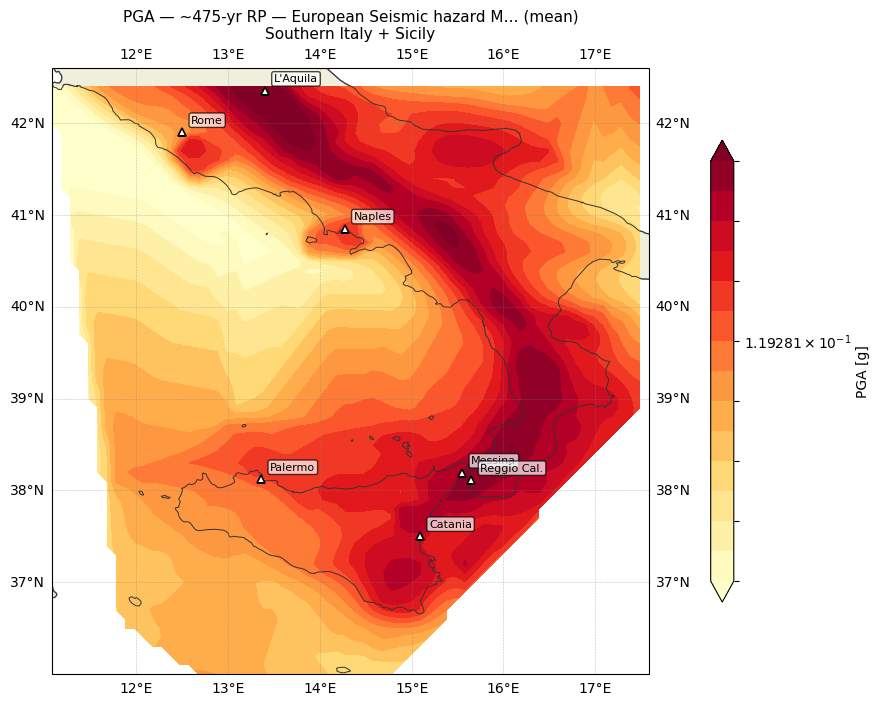

In [7]:
# ============================================================
#  EXERCISE A — Basic PGA map at ~475-yr return period
#  Edit settings and run.
# ============================================================
EX_A = {
    'model_name' : 'European Seismic hazard Model 2020 (ESHM20)',
    'imt'        : 'PGA',
    'soil'       : 'rock_vs30_800ms-1',
    'agg_type'   : 'arithmetic',
    'agg_level'  : '0.5',
    'region'     : 'Southern Italy + Sicily',
    'log_scale'  : True,
    'debug'      : False,
}

# ── Auto-resolve closest 475-yr PoE from probed values ──────────────────
try:
    poe_prob, poe_years = resolve_poe(EX_A['model_name'], target_rp=475)
except NameError:
    print('WARNING: run sections 2–6 first (imports, helpers, config, probe).')
    poe_prob, poe_years = None, None
if poe_prob is None:
    poe_prob, poe_years = '0.002103', '1'
    print(f'Using fallback PoE: {poe_prob} in {poe_years} yr')
else:
    print(f'Using probed PoE: prob={poe_prob}, years={poe_years}')

# --- Do not edit below this line ---
model = MODELS.get(EX_A['model_name'])
if model is None:
    print(f"Model not found. Options: {list(MODELS.keys())}")
else:
    map_a = fetch_map(
        model['id'], EX_A['imt'], poe_prob, poe_years,
        soil=EX_A['soil'],
        agg_type=EX_A['agg_type'], agg_level=EX_A['agg_level'],
        bbox=REGIONS[EX_A['region']],
        debug=EX_A['debug']
    )

    if map_a:
        print(f"  PGA range: {map_a['values'].min():.4f} – {map_a['values'].max():.4f} g")

        if HAS_CARTOPY:
            import cartopy.crs as ccrs
            fig, ax = plt.subplots(figsize=(10, 8),
                                   subplot_kw={'projection': ccrs.PlateCarree()})
            cf = plot_map_cartopy(
                map_a,
                title=f'PGA — ~475-yr RP — {EX_A["model_name"][:25]}… (mean)\n{EX_A["region"]}',
                ax=ax, log_scale=EX_A['log_scale'], show_colorbar=False)
            mark_cities(ax, CITIES, projection=ccrs.PlateCarree())
        else:
            fig, ax = plt.subplots(figsize=(10, 8))
            cf = plot_map_simple(
                map_a,
                title=f'PGA — ~475-yr RP — {EX_A["model_name"][:25]}… (mean)\n{EX_A["region"]}',
                ax=ax, log_scale=EX_A['log_scale'], show_colorbar=False)
            b = REGIONS[EX_A['region']]
            mark_cities(ax, [c for c in CITIES
                              if b[0] <= c['lon'] <= b[2] and b[1] <= c['lat'] <= b[3]])

        plt.colorbar(cf, ax=ax, label='PGA [g]', shrink=0.75, pad=0.08)
        if not HAS_CARTOPY:
            plt.tight_layout()
        plt.show()
    else:
        print('\n→ fetch_map failed. Run the debug cell to diagnose.')

## 8. Exercise B: Three return periods side by side

**Task:** Plot PGA maps for three return periods in a single figure:
- 101-yr RP (frequent shaking, ~39% in 50y)
- 475-yr RP (Eurocode design, 10% in 50y)
- 2500-yr RP (near-collapse, 2% in 50y)

**Learning goals:**
- Observe how the spatial pattern evolves with return period
- High-hazard zones are already apparent at short return periods, but low-hazard zones remain low — the *relative* pattern is stable
- Understand what it means to design at different safety levels

**Note:** All three maps use the same colour scale (`vmin` / `vmax`) so they are directly comparable.

  ~101-yr RP → using prob=0.00989, years=1 (~101-yr RP)
Fetching map: PGA, PoE=0.00989/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1847.zip
  ✓ 2153 points read from shapefile
  ✓ 2153 nodes  |  PGA range: 0.0076–0.1300 g
  ~475-yr RP → using prob=0.002103, years=1 (~476-yr RP)
Fetching map: PGA, PoE=0.002103/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1846.zip
  ✓ 2150 points read from shapefile
  ✓ 2150 nodes  |  PGA range: 0.0170–0.3700 g
  ~2500-yr RP → using prob=3.99999E-4, years=1 (~2500-yr RP)
Fetching map: PGA, PoE=3.99999E-4/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1844.zip
  ✓ 2155 points read from shapefile
  ✓ 2155 nodes  |  PGA range: 0.0369–0.8772 g


/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


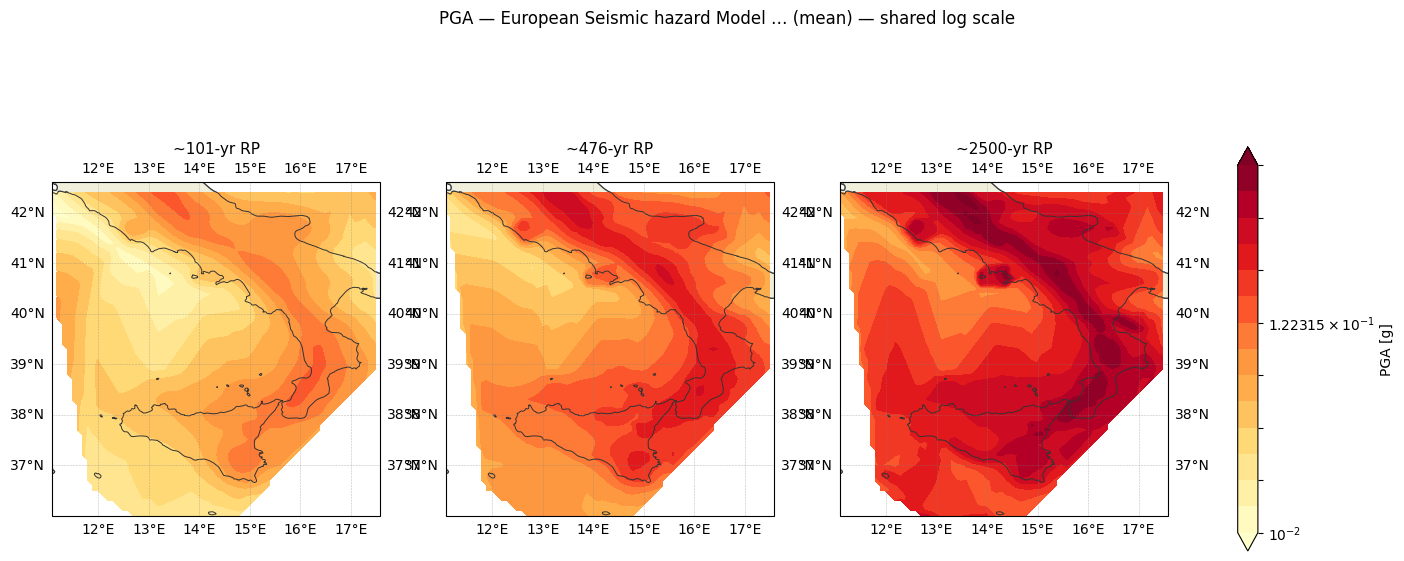

In [8]:
# ============================================================
#  EXERCISE B — Three return periods, shared colour scale
# ============================================================
EX_B = {
    'model_name': 'European Seismic hazard Model 2020 (ESHM20)',
    'imt'       : 'PGA',
    'soil'      : 'rock_vs30_800ms-1',
    'agg_type'  : 'arithmetic',
    'agg_level' : '0.5',
    'region'    : 'Southern Italy + Sicily',
    'target_rps': [101, 475, 2500],
    'vmin': 0.01, 'vmax': 0.80,
}

# --- Do not edit below this line ---
model = MODELS.get(EX_B['model_name'])
if model is None:
    print(f"Model not found. Options: {list(MODELS.keys())}")
else:
    maps_b = []
    for rp in EX_B['target_rps']:
        poe_prob, poe_years = resolve_poe(EX_B['model_name'], target_rp=rp)
        if poe_prob is None:
            print(f'  No PoE found for ~{rp}-yr RP — skipping')
            continue
        ar = float(poe_prob) if float(poe_years) == 1 else (
             -math.log(1 - float(poe_prob)) / float(poe_years))
        actual_rp = round(1 / ar)
        print(f'  ~{rp}-yr RP → using prob={poe_prob}, years={poe_years} (~{actual_rp}-yr RP)')
        m = fetch_map(model['id'], EX_B['imt'], poe_prob, poe_years,
                      soil=EX_B['soil'],
                      agg_type=EX_B['agg_type'], agg_level=EX_B['agg_level'],
                      bbox=REGIONS[EX_B['region']])
        if m:
            m['label'] = f'~{actual_rp}-yr RP'
            maps_b.append(m)

    if maps_b:
        ncols = len(maps_b)
        if HAS_CARTOPY:
            import cartopy.crs as ccrs
            fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 7),
                                     subplot_kw={'projection': ccrs.PlateCarree()})
        else:
            fig, axes = plt.subplots(1, ncols, figsize=(6*ncols, 7))
        if ncols == 1: axes = [axes]

        cfs = []
        for ax, m in zip(axes, maps_b):
            cf = plot_map(m, title=m['label'],
                          vmin=EX_B['vmin'], vmax=EX_B['vmax'],
                          ax=ax, log_scale=True, show_colorbar=False)
            cfs.append(cf)
        fig.suptitle(f'PGA — {EX_B["model_name"][:30]}… (mean) — shared log scale',
                     fontsize=12)
        plt.colorbar(cfs[-1], ax=axes, label='PGA [g]', shrink=0.75)
        if not HAS_CARTOPY:
            plt.tight_layout()
        plt.show()
    else:
        print('\n→ No maps fetched. Run the debug cell to diagnose.')

## 9. Exercise C: Epistemic uncertainty map (84th pct. − mean)

**Task:** Fetch the ESHM20 mean PGA map and the 84th-percentile PGA map at 475-yr RP, then compute and plot their difference.

**Learning goals:**
- Quantify *where* epistemic uncertainty is highest across the region
- The 84th-percentile map represents an upper bound on the model uncertainty
- High difference = high sensitivity to GMM / source-model choices; these regions are scientifically contested

> **Note:** The previous version of this exercise compared ESHM13 vs ESHM20 via the old XML API.  
> ESHM13 is not currently served by the new REST API, so we use within-ESHM20 epistemic uncertainty instead.  
> If you need ESHM13, use the legacy endpoint at `appsrvr.share-eu.org:8080/share`.

**Colour scale:** Diverging palette — red = 84th pct higher than mean; white = no spread.

PoE: 0.002103 in 1 yr
Fetching map: PGA, PoE=0.002103/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1846.zip
  ✓ 2150 points read from shapefile
  ✓ 2150 nodes  |  PGA range: 0.0170–0.3700 g
Fetching map: PGA, PoE=0.002103/1yr
  4b: shapefile ZIP download: https://efehrappsrvr.ethz.ch/share/staticdownload/hmap1986.zip
  ✓ 2150 points read from shapefile
  ✓ 2150 nodes  |  PGA range: 0.0223–0.5252 g


/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


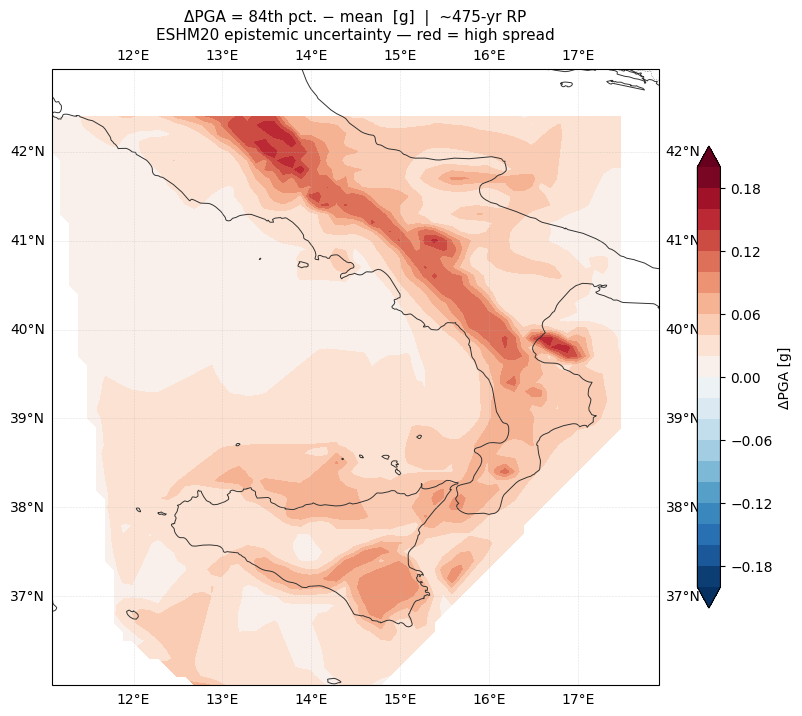

ΔPGA  mean=0.0366  p5=0.0098  p95=nan g


/home/romanoe/projects/notebooks/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


In [9]:
# ============================================================
#  EXERCISE C — Epistemic uncertainty map: 84th percentile − mean
# ============================================================
EX_C = {
    'model_name' : 'European Seismic hazard Model 2020 (ESHM20)',
    'imt'        : 'PGA',
    'soil'       : 'rock_vs30_800ms-1',
    'region'     : 'Southern Italy + Sicily',
    'target_rp'  : 475,
    'max_diff_g' : 0.20,
}

# --- Do not edit below this line ---
model = MODELS.get(EX_C['model_name'])
if model is None:
    print(f"Both mean and 84th-pct must be in config. Options: {list(MODELS.keys())}")
else:
    poe_prob, poe_years = resolve_poe(EX_C['model_name'], target_rp=EX_C['target_rp'])
    if poe_prob is None:
        poe_prob, poe_years = '0.002103', '1'

    print(f'PoE: {poe_prob} in {poe_years} yr')

    map_mean = fetch_map(model['id'], EX_C['imt'], poe_prob, poe_years,
                         soil=EX_C['soil'], agg_type='arithmetic', agg_level='0.5',
                         bbox=REGIONS[EX_C['region']])
    map_84   = fetch_map(model['id'], EX_C['imt'], poe_prob, poe_years,
                         soil=EX_C['soil'], agg_type='ordinal', agg_level='0.84',
                         bbox=REGIONS[EX_C['region']])

    if map_mean and map_84:
        grid_res = 0.1
        lon_min = max(map_mean['lons'].min(), map_84['lons'].min())
        lon_max = min(map_mean['lons'].max(), map_84['lons'].max())
        lat_min = max(map_mean['lats'].min(), map_84['lats'].min())
        lat_max = min(map_mean['lats'].max(), map_84['lats'].max())
        lon_g = np.arange(lon_min, lon_max + grid_res, grid_res)
        lat_g = np.arange(lat_min, lat_max + grid_res, grid_res)
        LON, LAT = np.meshgrid(lon_g, lat_g)

        V_mean = griddata((map_mean['lons'], map_mean['lats']), map_mean['values'],
                          (LON, LAT), method='linear')
        V_84   = griddata((map_84['lons'],   map_84['lats']),   map_84['values'],
                          (LON, LAT), method='linear')
        DIFF = np.ma.masked_invalid(V_84 - V_mean)

        clim   = EX_C['max_diff_g']
        levels = np.linspace(-clim, clim, 21)

        if HAS_CARTOPY:
            import cartopy.crs as ccrs, cartopy.feature as cfeature
            fig, ax = plt.subplots(figsize=(10, 8),
                                   subplot_kw={'projection': ccrs.PlateCarree()})
            cf = ax.contourf(LON, LAT, DIFF, levels=levels, cmap='RdBu_r',
                             extend='both', transform=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE, linewidth=0.7, color='0.2')
            ax.add_feature(cfeature.BORDERS,   linewidth=0.5, color='0.4', linestyle=':')
            ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle='--')
        else:
            fig, ax = plt.subplots(figsize=(10, 8))
            cf = ax.contourf(LON, LAT, DIFF, levels=levels, cmap='RdBu_r', extend='both')
            ax.set_xlabel('Longitude [°E]'); ax.set_ylabel('Latitude [°N]')
            ax.set_aspect('equal')
            ax.grid(True, linewidth=0.4, alpha=0.4, linestyle='--')

        ax.contour(LON, LAT, DIFF, levels=[0], colors='k', linewidths=1.5)
        ax.set_title(f'ΔPGA = 84th pct. − mean  [g]  |  ~{EX_C["target_rp"]}-yr RP\n'
                     f'ESHM20 epistemic uncertainty — red = high spread', fontsize=11)
        plt.colorbar(cf, ax=ax, label='ΔPGA [g]', shrink=0.75)
        if not HAS_CARTOPY:
            plt.tight_layout()
        plt.show()
        print(f'ΔPGA  mean={np.nanmean(DIFF):.4f}  '
              f'p5={np.nanpercentile(DIFF,5):.4f}  '
              f'p95={np.nanpercentile(DIFF,95):.4f} g')
    else:
        print('\n→ One or both maps failed. Run the debug cell to diagnose.')

## 10. Exercise D: Spectral ratio map SA[0.2s] / PGA

**Task:** Fetch PGA and SA[0.2s] maps at the same return period and compute their ratio. Plot the ratio map.

**Physical interpretation:** The ratio SA[0.2s]/PGA is a proxy for the *spectral amplification factor* at 0.2 s — how much more a short-period structure (T ≈ 0.2 s, roughly a 2-storey building) shakes compared to the ground itself. Where this ratio is high, the dominant seismic frequencies match the natural frequency of short-period structures. This reflects the frequency content of the ground motion, which is controlled by source-to-site distance, magnitude distribution, and crustal structure.

**Expected pattern:** The ratio tends to be higher close to large-magnitude source zones where near-field pulses dominate, and lower at sites receiving only high-frequency distant earthquakes.

In [ ]:
# ============================================================
#  EXERCISE D — Spectral ratio map SA[0.2s] / PGA
# ============================================================
EX_D = {
    'model_name' : 'European Seismic hazard Model 2020 (ESHM20)',
    'soil'       : 'rock_vs30_800ms-1',
    'agg_type'   : 'arithmetic',
    'agg_level'  : '0.5',
    'poe_prob'   : '0.002103',  # 475-yr RP annual rate
    'poe_years'  : '1',
    'region'     : 'Southern Italy + Sicily',
}

# --- Do not edit below this line ---
model = MODELS.get(EX_D['model_name'])
if model is None:
    print(f"Model not found. Options: {list(MODELS.keys())}")
else:
    print('Fetching PGA map...')
    map_pga = fetch_map(model['id'], 'PGA',
                        EX_D['poe_prob'], EX_D['poe_years'],
                        soil=EX_D['soil'],
                        agg_type=EX_D['agg_type'], agg_level=EX_D['agg_level'],
                        bbox=REGIONS[EX_D['region']])

    print('Fetching SA[0.20s] map...')
    map_sa02 = fetch_map(model['id'], 'SA[0.20s]',
                         EX_D['poe_prob'], EX_D['poe_years'],
                         soil=EX_D['soil'],
                         agg_type=EX_D['agg_type'], agg_level=EX_D['agg_level'],
                         bbox=REGIONS[EX_D['region']])

    if map_pga and map_sa02:
        grid_res = 0.1
        lon_min = max(map_pga['lons'].min(), map_sa02['lons'].min())
        lon_max = min(map_pga['lons'].max(), map_sa02['lons'].max())
        lat_min = max(map_pga['lats'].min(), map_sa02['lats'].min())
        lat_max = min(map_pga['lats'].max(), map_sa02['lats'].max())

        lon_g = np.arange(lon_min, lon_max + grid_res, grid_res)
        lat_g = np.arange(lat_min, lat_max + grid_res, grid_res)
        LON, LAT = np.meshgrid(lon_g, lat_g)

        V_PGA  = griddata((map_pga['lons'],  map_pga['lats']),  map_pga['values'],
                          (LON, LAT), method='linear')
        V_SA02 = griddata((map_sa02['lons'], map_sa02['lats']), map_sa02['values'],
                          (LON, LAT), method='linear')

        with np.errstate(divide='ignore', invalid='ignore'):
            RATIO = np.where(V_PGA > 0, V_SA02 / V_PGA, np.nan)
        RATIO = np.ma.masked_invalid(RATIO)

        levels = np.linspace(0.5, 3.0, 21)

        if HAS_CARTOPY:
            import cartopy.crs as ccrs
            import cartopy.feature as cfeature
            fig, ax = plt.subplots(figsize=(10, 8),
                                   subplot_kw={'projection': ccrs.PlateCarree()})
            cf = ax.contourf(LON, LAT, RATIO, levels=levels, cmap='plasma',
                             extend='both', transform=ccrs.PlateCarree())
            ax.add_feature(cfeature.COASTLINE, linewidth=0.7, color='0.2')
            ax.add_feature(cfeature.BORDERS,   linewidth=0.5, color='0.4', linestyle=':')
            ax.gridlines(draw_labels=True, linewidth=0.4, alpha=0.4, linestyle='--')
        else:
            fig, ax = plt.subplots(figsize=(10, 8))
            cf = ax.contourf(LON, LAT, RATIO, levels=levels, cmap='plasma', extend='both')
            ax.set_xlabel('Longitude [°E]')
            ax.set_ylabel('Latitude [°N]')
            ax.set_aspect('equal')
            ax.grid(True, linewidth=0.4, alpha=0.4, linestyle='--')

        ax.set_title('Spectral Ratio SA[0.2s] / PGA  |  475-yr RP  |  ESHM20 mean\n'
                     'High values → short-period structures face proportionally higher demand',
                     fontsize=11)
        plt.colorbar(cf, ax=ax, label='SA[0.2s] / PGA  [dimensionless]', shrink=0.75)
        if not HAS_CARTOPY:
            plt.tight_layout()
        plt.show()

        print(f'Ratio range: {np.nanmin(RATIO):.2f} – {np.nanmax(RATIO):.2f}')
        _ratio_vals = np.array(RATIO.filled(np.nan)).ravel()
        _valid = ~np.isnan(_ratio_vals)
        messina_ratio = float(griddata(
            (LON.ravel()[_valid], LAT.ravel()[_valid]),
            _ratio_vals[_valid],
            [[15.55, 38.19]],
            method='nearest'
        )[0])
        print(f'Ratio at approximate Messina location: {messina_ratio:.2f}')

## 11. Exercise E: Interactive folium map with WMS overlay and OGC source features

**Task:** Create an interactive HTML map that combines:
1. A **WMS hazard tile layer** from `efehr-services.ethz.ch/hazard/ows/eshm20-output` (server-rendered, always up-to-date)
2. Scattered grid points from `/v1/maps/area` (coloured circles)
3. **ESHM20 input features** from the OGC API — active faults and/or earthquake catalogue
4. City markers with site-specific PGA values

**Learning goals:**
- WMS tiles let you add a pre-rendered hazard layer without downloading all grid points
- The OGC API provides access to ESHM20 *input* data (sources, faults, catalogue) directly as GeoJSON
- Interactive maps are the standard output for communicating seismic hazard to practitioners

In [ ]:
# ============================================================
#  EXERCISE E — Interactive folium web map
#  Requires: folium installed (Cell 1) and map_a from Exercise A
# ============================================================
FOLIUM_OUTPUT = 'hazard_map_interactive.html'

if not HAS_FOLIUM:
    print('folium not available. Install it with: pip install folium')
elif 'map_a' not in vars() or map_a is None:
    print('Run Exercise A first to fetch the map data.')
else:
    import folium
    from folium import plugins

    # ── Centre the map on the study region ────────────────────────────
    centre_lat = (map_a['lats'].min() + map_a['lats'].max()) / 2
    centre_lon = (map_a['lons'].min() + map_a['lons'].max()) / 2

    fmap = folium.Map(location=[centre_lat, centre_lon],
                      zoom_start=7,
                      tiles='CartoDB positron')

    # ── Build a colour-mapped circle marker for each grid node ────────
    # Normalise to [0,1] on log scale for colour mapping
    vals_log = np.log10(np.clip(map_a['values'], 1e-5, None))
    vmin_log = np.percentile(vals_log, 2)
    vmax_log = np.percentile(vals_log, 98)
    norm_vals = np.clip((vals_log - vmin_log) / (vmax_log - vmin_log), 0, 1)

    cmap_fn = plt.get_cmap('YlOrRd')

    def to_hex(v):
        r, g, b, _ = cmap_fn(float(v))
        return f'#{int(r*255):02x}{int(g*255):02x}{int(b*255):02x}'

    # Only plot a representative subset if grid is very dense
    step = max(1, len(map_a['lons']) // 3000)
    print(f'Plotting {len(map_a["lons"][::step])} / {len(map_a["lons"])} grid nodes...')

    for lon, lat, val, nv in zip(map_a['lons'][::step],
                                  map_a['lats'][::step],
                                  map_a['values'][::step],
                                  norm_vals[::step]):
        folium.CircleMarker(
            location=[lat, lon],
            radius=4,
            color=None,
            fill=True,
            fill_color=to_hex(nv),
            fill_opacity=0.7,
            tooltip=f'PGA = {val:.4f} g'
        ).add_to(fmap)

    # ── Add city markers ──────────────────────────────────────────────
    bbox = REGIONS['Southern Italy + Sicily']
    for city in CITIES:
        if bbox[0] <= city['lon'] <= bbox[2] and bbox[1] <= city['lat'] <= bbox[3]:
            # Find nearest grid node
            dists = np.hypot(map_a['lons'] - city['lon'], map_a['lats'] - city['lat'])
            nearest_idx = np.argmin(dists)
            pga_city = map_a['values'][nearest_idx]

            folium.Marker(
                location=[city['lat'], city['lon']],
                popup=folium.Popup(
                    f"<b>{city['name']}</b><br>"
                    f"PGA (475-yr, rock) = {pga_city:.4f} g<br>"
                    f"ESHM20 mean",
                    max_width=200
                ),
                tooltip=city['name'],
                icon=folium.Icon(color='darkblue', icon='home')
            ).add_to(fmap)

    # ── Add a simple legend ──────────────────────────────────────────
    legend_html = """
    <div style="position:fixed;bottom:40px;left:40px;z-index:1000;background:white;
                padding:10px;border:1px solid #ccc;border-radius:5px;font-size:12px">
    <b>PGA [g] — 475-yr RP</b><br>
    <i>ESHM20 mean — rock (Vs30 800 m/s)</i><br><br>
    <svg width="150" height="18"><defs>
      <linearGradient id="lg"><stop offset="0%" stop-color="#ffffb2"/>
      <stop offset="50%" stop-color="#fd8d3c"/><stop offset="100%" stop-color="#bd0026"/>
      </linearGradient></defs>
      <rect width="150" height="18" fill="url(#lg)"/></svg><br>
    Low &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; High
    </div>"""
    fmap.get_root().html.add_child(folium.Element(legend_html))

    fmap.save(FOLIUM_OUTPUT)
    print(f'Interactive map saved to: {FOLIUM_OUTPUT}')
    print('Open the .html file in a browser to explore the interactive map.')
    print('Click on city markers (home icons) to see PGA values.')

    # Optionally render inline in JupyterLab:
    try:
        from IPython.display import IFrame, display
        display(IFrame(FOLIUM_OUTPUT, width='100%', height='600px'))
    except Exception:
        print('(Could not embed inline — open the .html file in a browser)')

## 12. Debug: inspect raw API responses

Use this cell when `fetch_map()` returns None or produces unexpected results. It queries the three main endpoints directly and prints concise summaries:
1. `/v1/maps/reference` — confirms the WMS layer name
2. `/v1/maps/area` — confirms the grid-point JSON response
3. OGC API `/collections` — lists available input dataset collections

In [ ]:
# ============================================================
#  CELL 11 — Detailed /map cascade diagnostics
#
#  Use this when fetch_map() fails. It walks all 4 levels
#  and prints full raw responses so you can see exactly
#  what the server returns at each step.
# ============================================================
DEBUG_MAP = {
    'model_id'  : '81',
    'imt'       : 'PGA',
    'soil'      : 'rock_vs30_800ms-1',
    'agg_type'  : 'arithmetic',
    'agg_level' : '0.5',
    'n_chars'   : 1200,
}

import math

# ── Levels 1–3 (raw XML) ────────────────────────────────────────────────────
poe_prob, poe_years = resolve_poe(
    next((m['name'] for m in config['available_models'] if m['id'] == DEBUG_MAP['model_id']), ''),
    target_rp=475)
if poe_prob is None:
    poe_prob, poe_years = '0.002103', '1'

print(f'Using PoE: {poe_prob} in {poe_years} yr\n')

probe_map_raw(
    DEBUG_MAP['model_id'], DEBUG_MAP['imt'],
    poe_prob=poe_prob, poe_years=poe_years,
    agg_type=DEBUG_MAP['agg_type'], agg_level=DEBUG_MAP['agg_level'],
    soil=DEBUG_MAP['soil'], n_chars=DEBUG_MAP['n_chars']
)

# ── Level 4: inspect the data URL ───────────────────────────────────────────
print('\n--- Level 4: data download ---')
ref = get_map_reference(
    DEBUG_MAP['model_id'], DEBUG_MAP['imt'],
    poe_prob, poe_years,
    DEBUG_MAP['agg_type'], DEBUG_MAP['agg_level'],
    DEBUG_MAP['soil'], debug=True)

if ref:
    loc = ref.get('hazardmaplocation')
    wms = ref.get('hmapwms')
    mid = ref.get('hmapid')
    print(f'\n  hmapid:           {mid}')
    print(f'  hmapwms:          {wms}')
    print(f'  hazardmaplocation:{loc}')

    if loc:
        print(f'\nFetching data from hazardmaplocation...')
        try:
            r = requests.get(loc, timeout=60)
            print(f'HTTP {r.status_code}  |  {len(r.text)} chars  |  '
                  f'Content-Type: {r.headers.get("Content-Type","?")}')
            print(f'\nFirst {DEBUG_MAP["n_chars"]} chars:')
            print(r.text[:DEBUG_MAP['n_chars']])
        except Exception as e:
            print(f'Error: {e}')

    if wms:
        print(f'\nShapefile ZIP URL:')
        print(f'  https://efehrappsrvr.ethz.ch/share/staticdownload/{wms}.zip')
else:
    print('Level 3 (get_map_reference) returned None.')
    print('Check Levels 1–3 output above for the cause.')

## Summary of exercises

| Ex. | Section | What was mapped | Key question |
|-----|---------|-----------------|-------------|
| A | 7 | PGA — single RP — Southern Italy | Which structural zone has highest hazard? |
| B | 8 | PGA — three RPs, shared colour scale | How do spatial patterns shift with RP? |
| C | 9 | ESHM20: 84th pct. − mean difference | Where is epistemic uncertainty highest? |
| D | 10 | Spectral ratio SA[0.2s]/PGA | Where are short-period structures most at risk? |
| E | 11 | Interactive folium: WMS + OGC faults | How do source zones correlate with hazard? |

### API services used

| Service | Endpoint | Purpose |
|---------|----------|---------|
| REST JSON API | `/v1/maps/area` | Hazard grid points (JSON) |
| REST JSON API | `/v1/maps/reference` | WMS layer name lookup |
| WMS | `ows/eshm20-output` | Pre-rendered hazard tiles |
| OGC API Features | `ows/eshm20-input/ogcapi` | Active faults, source zones, catalogue |

### Further exploration

- **Change the region:** Edit `'region'` in any exercise to `'Italy'` or `'Central Mediterranean'` to zoom out.
- **Map SA at long periods:** Replace `'PGA'` with `'SA[1.00s]'` or `'SA[2.00s]'` in Exercise A and compare the spatial pattern.
- **OGC earthquake catalogue:** Modify Exercise E to also fetch `fetch_ogc_features('catalogue', bbox=bbox)` and add earthquake markers coloured by magnitude.
- **Area source zones:** Use `fetch_ogc_features('area_source_model', bbox=bbox)` to overlay the ESHM20 seismicity zones on the hazard map and discuss the spatial correlation.

*EFEHR Services API — https://efehr-services.ethz.ch/hazard/api*  
*OGC API — https://efehr-services.ethz.ch/hazard/ows/eshm20-input/ogcapi*  
*WMS — https://efehr-services.ethz.ch/hazard/ows/eshm20-output*  
*International Training Course — Potsdam, June 2026*